In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader as data
import yfinance as yf


In [7]:
start = '2017-01-01'
end = '2023-11-1'

df = yf.download("AAPL", start=start, end=end, auto_adjust=False)
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2017-01-03,26.745859,29.037500,29.082500,28.690001,28.950001,115127600
2017-01-04,26.715925,29.004999,29.127501,28.937500,28.962500,84472400
2017-01-05,26.851782,29.152500,29.215000,28.952499,28.980000,88774400
2017-01-06,27.151129,29.477501,29.540001,29.117500,29.195000,127007600
2017-01-09,27.399820,29.747499,29.857500,29.485001,29.487499,134247600


In [8]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2023-10-25,169.118011,171.100006,173.059998,170.649994,171.880005,57157000
2023-10-26,164.956772,166.889999,171.380005,165.669998,170.369995,70625300
2023-10-27,166.271378,168.220001,168.960007,166.830002,166.910004,58499100
2023-10-30,168.317368,170.289993,171.169998,168.869995,169.020004,51131000
2023-10-31,168.791840,170.770004,170.899994,167.899994,169.350006,44846000


In [9]:
df = df.reset_index()
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
0,2017-01-03,26.745859,29.037500,29.082500,28.690001,28.950001,115127600
1,2017-01-04,26.715925,29.004999,29.127501,28.937500,28.962500,84472400
2,2017-01-05,26.851782,29.152500,29.215000,28.952499,28.980000,88774400
3,2017-01-06,27.151129,29.477501,29.540001,29.117500,29.195000,127007600
4,2017-01-09,27.399820,29.747499,29.857500,29.485001,29.487499,134247600


In [10]:
df = df.drop(["Date","Adj Close"], axis =1)
df.head()

/tmp/ipykernel_16313/4201024111.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(["Date","Adj Close"], axis =1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,29.037500,29.082500,28.690001,28.950001,115127600
1,29.004999,29.127501,28.937500,28.962500,84472400
2,29.152500,29.215000,28.952499,28.980000,88774400
3,29.477501,29.540001,29.117500,29.195000,127007600
4,29.747499,29.857500,29.485001,29.487499,134247600


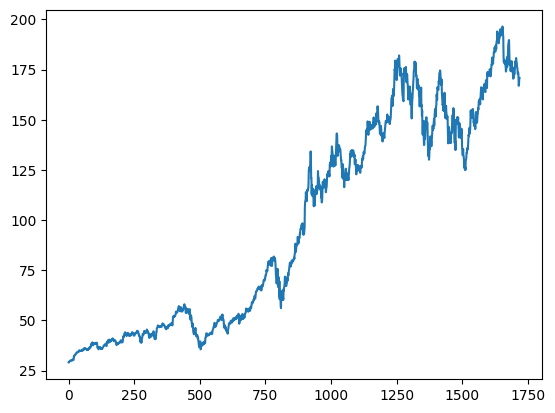

In [11]:
plt.plot(df.Close)

In [12]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1714,182.286601
1715,182.159701
1716,182.049801
1717,181.974501


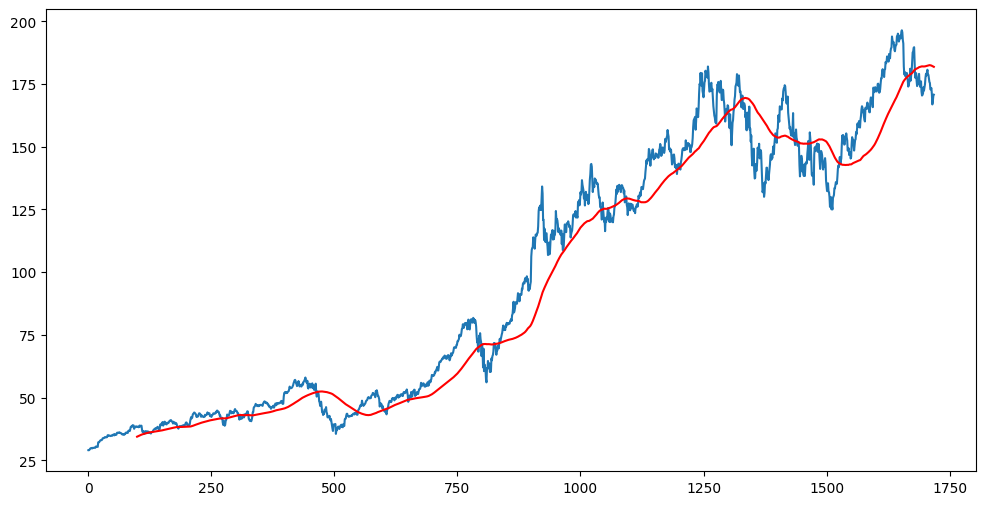

In [13]:
plt.figure(figsize =(12 ,6))
plt.plot(df.Close)
plt.plot(ma100,"r")

In [14]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1714,170.17610
1715,170.35690
1716,170.53055
1717,170.71495


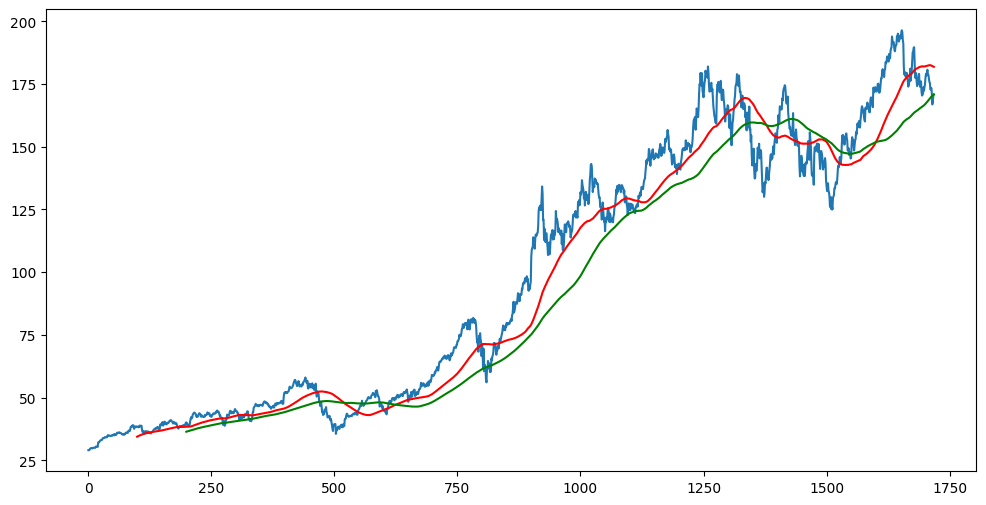

In [15]:
plt.figure(figsize =(12 ,6))
plt.plot(df.Close)
plt.plot(ma100,"r")
plt.plot(ma200,"g")

In [16]:
df.shape

(1719, 5)

In [17]:
#Splitting Data into Training and Testing

data_training = pd.DataFrame(df['Close'][0: int(len(df)*0.78)])
data_testing= pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])



print(data_training.shape)

print(data_testing.shape)

(1340, 1)
(516, 1)


In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [19]:
data_training_array= scaler.fit_transform(data_training)
data_training_array

array([[2.12419344e-04],
       [0.00000000e+00],
       [9.64027295e-04],
       ...,
       [8.35234194e-01],
       [8.33731003e-01],
       [8.79938592e-01]], shape=(1340, 1))

In [20]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train , y_train =np.array(x_train) , np.array(y_train)

In [21]:
from keras. layers import Dense, Dropout ,LSTM

from keras.models import Sequential

2026-03-01 12:50:46.451770: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 12:50:47.377366: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 12:50:51.621860: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [22]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1], 1)))
model.add(Dropout (0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout (0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout (0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout (0.5))

model.add(Dense(units=1))

E0000 00:00:1772344252.913577   16313 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772344252.921585   16313 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/bbernhard/Documents/Bengkod/sertifikasi/new/Stock-Market/venv/lib64/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam', loss ='mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - loss: 0.0610
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - loss: 0.0112
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - loss: 0.0089
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - loss: 0.0074
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - loss: 0.0071
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - loss: 0.0070
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - loss: 0.0082
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - loss: 0.0078
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - loss: 0.0059
Epoch 10/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 0.0063
Epoch 11/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - loss: 0.0061
Epoch 12/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step - loss: 0.0052
Epoch 13/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 248ms/step - loss: 0.0060
Epoch 14/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - loss: 0.0053
Epoch 15/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/ste

In [28]:
model.save("keras_model.keras")

In [27]:
past_100_days = data_training.tail(100)

final_df = past_100_days.append(data_testing, ignore_index=True)
final_df.head()

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
input_data=scaler.fit_transform(final_df)
input_data

In [ ]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

x_test , y_test =np.array(x_test) , np.array(y_test)

In [ ]:
#predication making
y_predication = model.predict(x_test)

17/17 [==============================] - 2s 84ms/step


In [ ]:
scaler.scale_

array([0.01399972])

In [ ]:
scaling_factor = 1/0.01399972
y_test = y_test*scaling_factor
y_predication=y_predication*scaling_factor

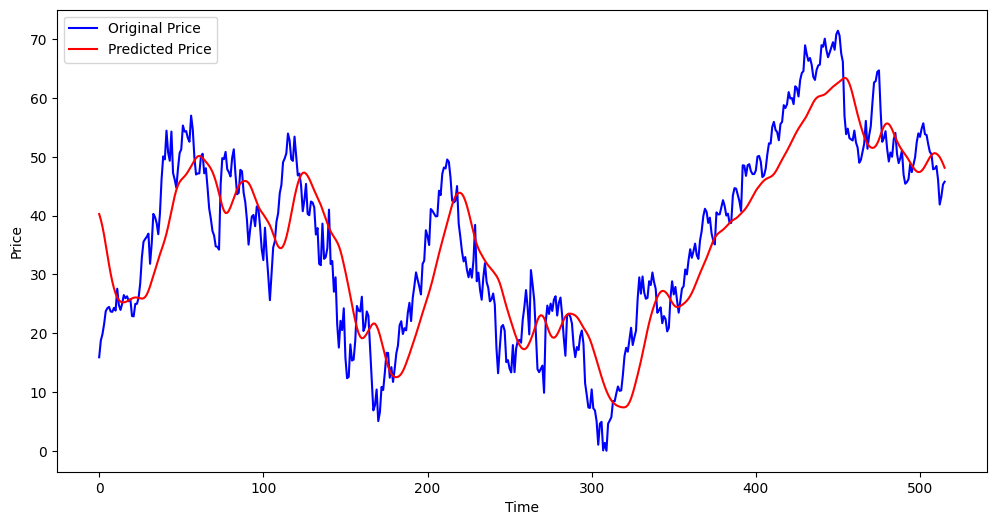

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predication,'r', label ='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()